## README:

* Cells labeled with '## ----- CONFIG ----- ##' contain parameters that need to be set manually 

In [1]:
import os
import sys

In [2]:
# add project root to path
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_path)

In [3]:
from dotenv import load_dotenv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F

from gymnasium import spaces
from finrl.meta.preprocessor.preprocessors import data_split
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnRewardThreshold
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

from trading_environment.custom_env import StockTradingEnv
from experiments.early_stopping import MultiCondEarlyStop
from evaluation.backtest import run_backtest
from evaluation.visualize import plot_trades_on_price_from_backtest


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## Load env variables

In [4]:
load_dotenv(r'../.env')

DATA_DIR = os.getenv('DATA_DIR')

## MLP feature extractor

In [5]:
class SimpleMLP(nn.Module):
    def __init__(
        self, input_dim: int, hidden_dim: int = 64, output_dim: int = 1
    ):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x: [batch_size, input_dim]
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

In [6]:
class MLPFeaturesExtractor(BaseFeaturesExtractor):
    """
    Wrap SimpleMLP as a feature extractor.
    """
    def __init__(
        self, observation_space: spaces.Box, features_dim: int = 64
    ):
        super().__init__(observation_space, features_dim)

        # use the latest (current) state, ignore lagged states
        input_dim = observation_space.shape[1]

        self.mlp = SimpleMLP(
            input_dim=input_dim, 
            hidden_dim=features_dim, 
            output_dim=features_dim
        )

    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        # observations: [batch_size, 100, 71]
        x = observations[:, -1, :] # get current state
        return self.mlp(x)

## Train-test split and normalization

In [7]:
## ----- CONFIG ----- ##
SPLIT_DATE = '2018-01-01' # format %Y-%m-%d
DATA_FILE_NAME = 'data_with_features.csv'

stock_features = [
    'atr_30',
    'macd',
    'macd_hist',
    'rsi_30'
]

economy_features = [
    'CPIAUCSL',
    'DFF',
    'ICSA',
    'T10Y2Y',
    'USEPUINDXD',
    'VIXCLS',
    'doy_sin',
    'doy_cos',
    'dow_sin',
    'dow_cos'
]

In [8]:
# load finalized data
data_df = pd.read_csv(os.path.join(DATA_DIR, DATA_FILE_NAME))
data_df['date'] = pd.to_datetime(data_df['date'], format='%Y-%m-%d')
data_df.shape

(67300, 35)

In [9]:
SPLIT_DATE = pd.to_datetime(SPLIT_DATE, format='%Y-%m-%d')

# train-test split
min_date = data_df['date'].min()
max_date = data_df['date'].max()

train_df = data_split(data_df, start=min_date, end=SPLIT_DATE)
trade_df = data_split(data_df, start=SPLIT_DATE + pd.Timedelta(days=1), end=max_date)

print(train_df.shape, trade_df.shape)

(47340, 35) (19950, 35)


In [10]:
stock_names = data_df['tic'].unique()
features_to_normalize = stock_features + economy_features

# normalize train/test data on training statistics
# Initialize StandardScaler
scaler = StandardScaler()

for tic in stock_names:
  for feature in features_to_normalize:
    # Fit scaler only on training data features to avoid data leakage
    train_df.loc[train_df['tic'] == tic, feature] = scaler.fit_transform(
      train_df.loc[train_df['tic'] == tic, feature].values.reshape(-1, 1))
    # Transform both training and trading data features using the fitted scaler
    trade_df.loc[trade_df['tic'] == tic, feature] = scaler.transform(
      trade_df.loc[trade_df['tic'] == tic, feature].values.reshape(-1, 1))


# check for NAs
print('Any missing values in training:', train_df.isna().any().any())
print('Any missing values in testing:', trade_df.isna().any().any())

Any missing values in training: False
Any missing values in testing: False


## Environment configuration

In [11]:
## ----- CONFIG ----- ##
price = 'close'         # name of price to use for transactions / rewards
hmax = 100              # maximum number of stocks to transact at each step
initial_amount = 5000   # initial amount of cash
buy_cost_pct = 0.005    # % cost of each stock purchase
sell_cost_pct = 0.005   # % cost of each stock sale
num_stock_shares = 0    # number of starting shares
window_size = 100       # number of previous time steps to encode
reward_scaling = 1      # reward scaling

In [12]:
# environment kwargs
stock_dim = len(data_df['tic'].unique())
state_space = 1 + 2 * stock_dim + len(stock_features) * stock_dim + len(economy_features)

env_kwargs = {
    "price": price,
    "hmax": hmax,
    "initial_amount": initial_amount,
    "buy_cost_pct": [buy_cost_pct] * stock_dim,
    "sell_cost_pct": [sell_cost_pct] * stock_dim,
    "stock_dim": stock_dim,
    "state_space": state_space,
    "action_space": stock_dim,
    "reward_scaling": 1,
    "num_stock_shares": [num_stock_shares] * stock_dim,
    "price": "close",
    "stock_features": stock_features,
    "economy_features": economy_features,
    "window_size": window_size
}


## Model training

In [13]:
# build training env
env_train_vec = DummyVecEnv([lambda: Monitor(StockTradingEnv(df=train_df, **env_kwargs))])

In [14]:
policy_kwargs = dict(
    net_arch=[64, 64],
    lstm_hidden_size=16,
    n_lstm_layers=1,
    shared_lstm=False,
    enable_critic_lstm=True,
    features_extractor_class=MLPFeaturesExtractor,
    features_extractor_kwargs=dict(features_dim=64),
)

model = RecurrentPPO(
    policy="MlpLstmPolicy",
    env=env_train_vec,

    # --- PPO rollout & update ---
    n_steps=64,
    batch_size=32,
    n_epochs=5,
    gamma=0.99,
    gae_lambda=0.95,

    # --- Optimization ---
    learning_rate=3e-4,
    max_grad_norm=0.5,
    clip_range=0.15,
    vf_coef=0.5,
    ent_coef=0.10,

    # --- Misc ---
    verbose=0,
    tensorboard_log=None,
    policy_kwargs=policy_kwargs,
)

In [ ]:
callback = MultiCondEarlyStop(
    loss_threshold=1e-7,
    loss_window=4,
    max_time_seconds=60,
    verbose=1,
)

model.learn(total_timesteps=10_000_000, callback=callback)

[MultiCondEarlyStop] train/loss = 90483.054688
[MultiCondEarlyStop] train/loss = 38488.597656
[MultiCondEarlyStop] train/loss = 67578.375000

📉 Stopping: train/loss in past 3 steps< 100000
Average: 65516.6758


## Quick evaluation

In [ ]:
# build trading/backtest env
env_trade_vec = DummyVecEnv([lambda: Monitor(StockTradingEnv(df=trade_df, **env_kwargs))])

In [17]:
res = run_backtest(
    model,
    env_trade_vec,
    env_kwargs
)

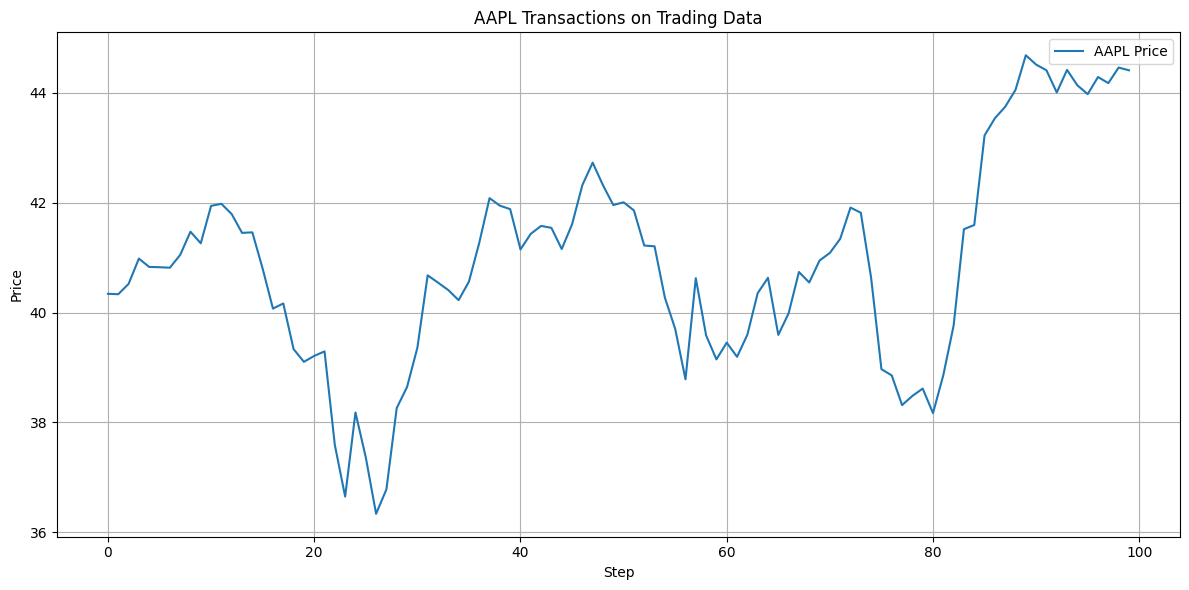

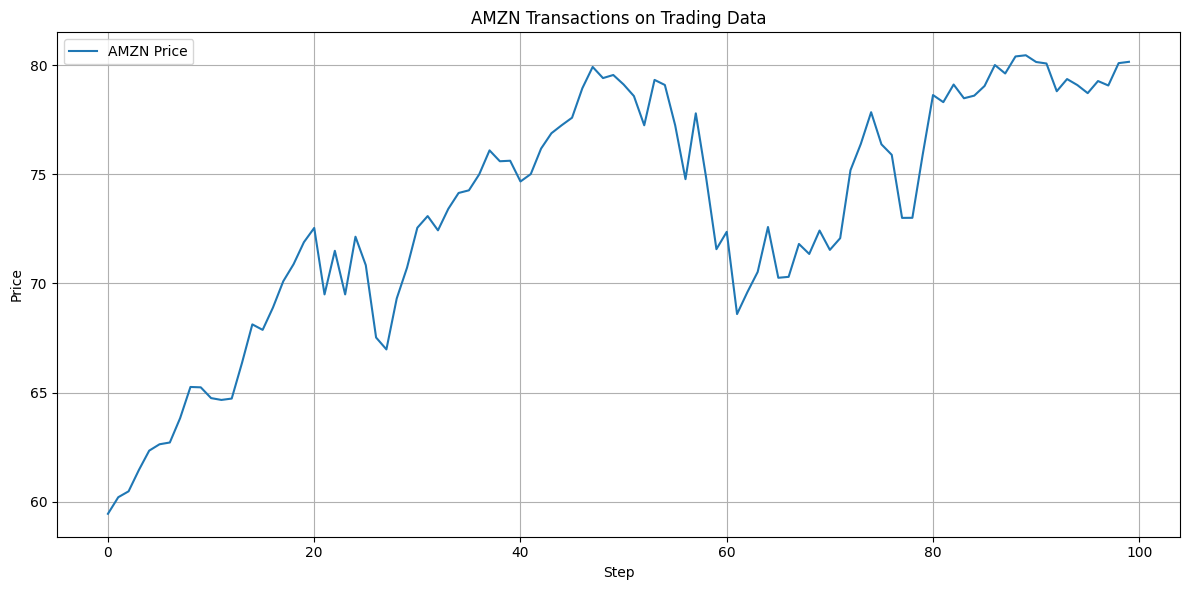

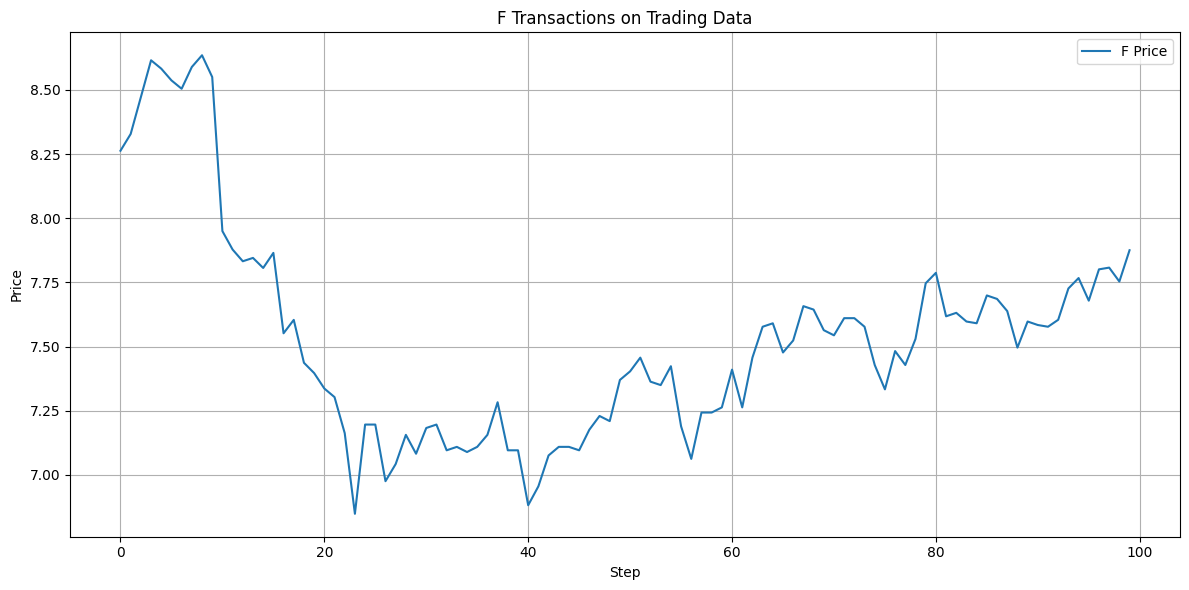

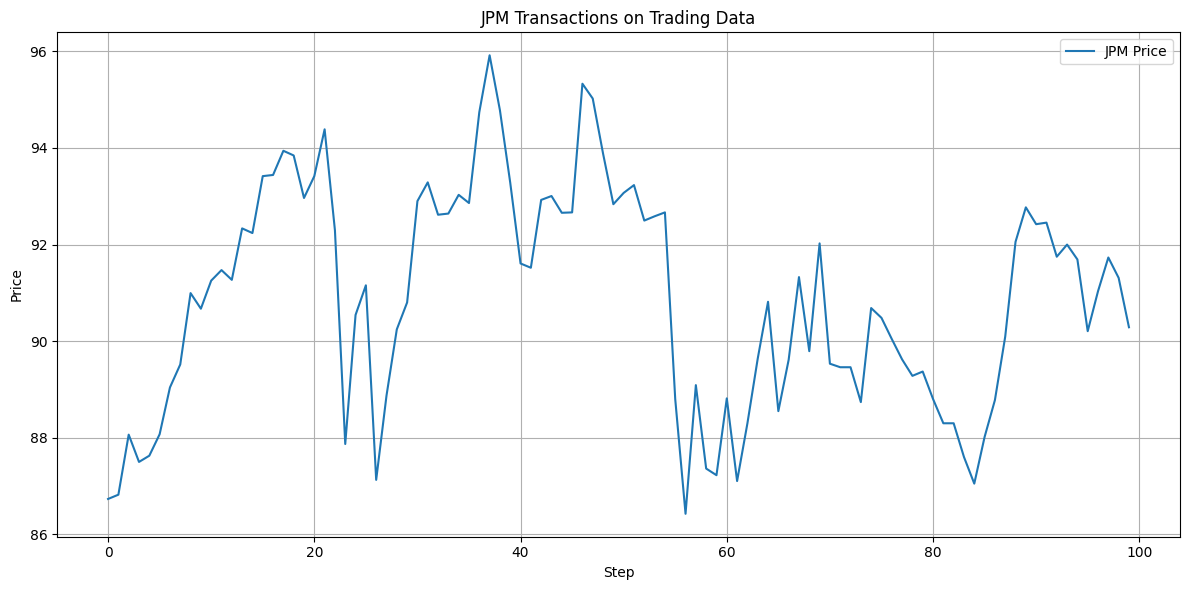

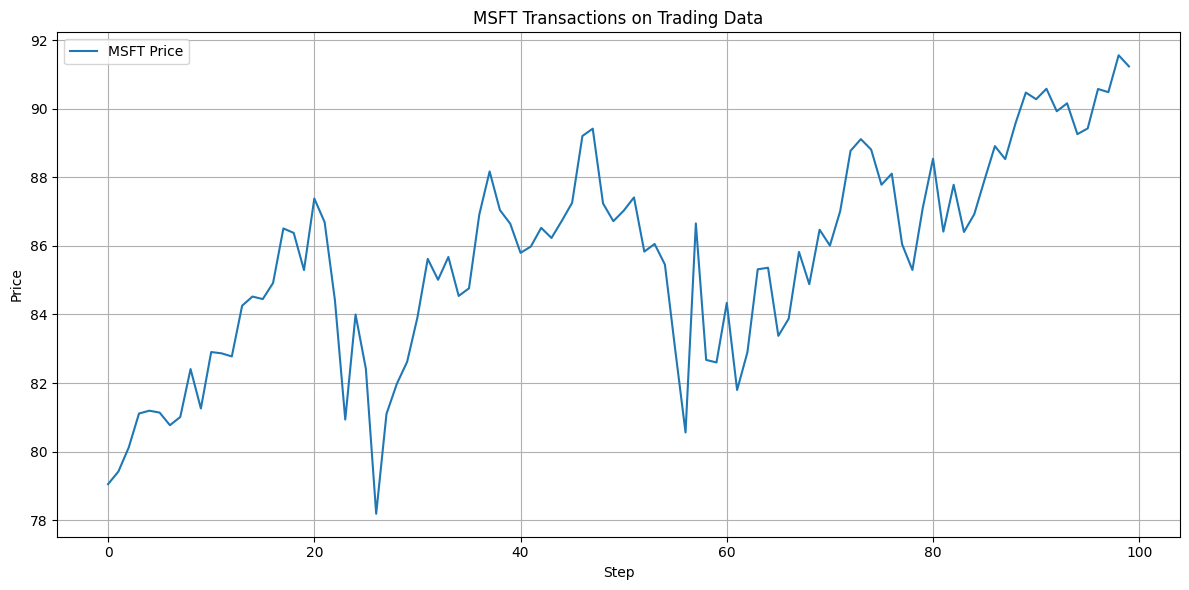

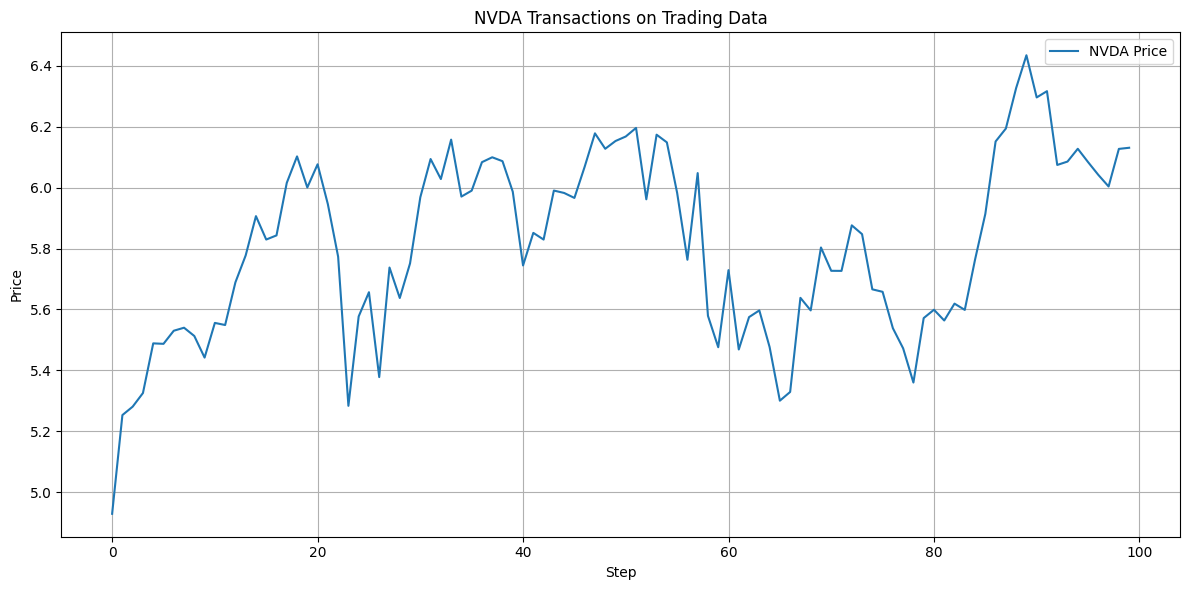

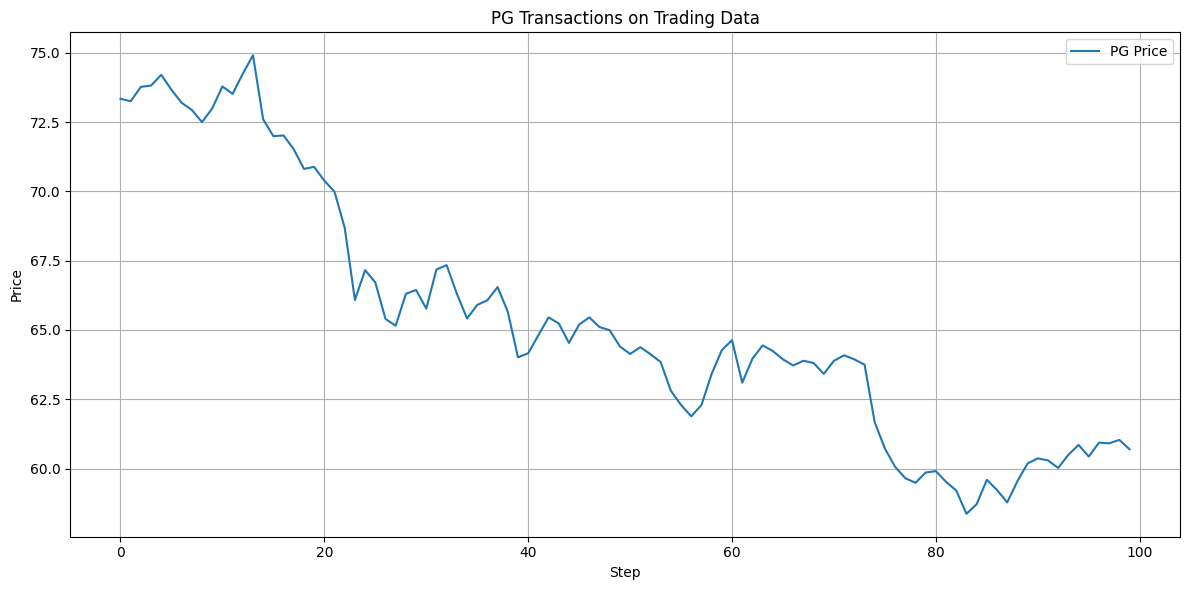

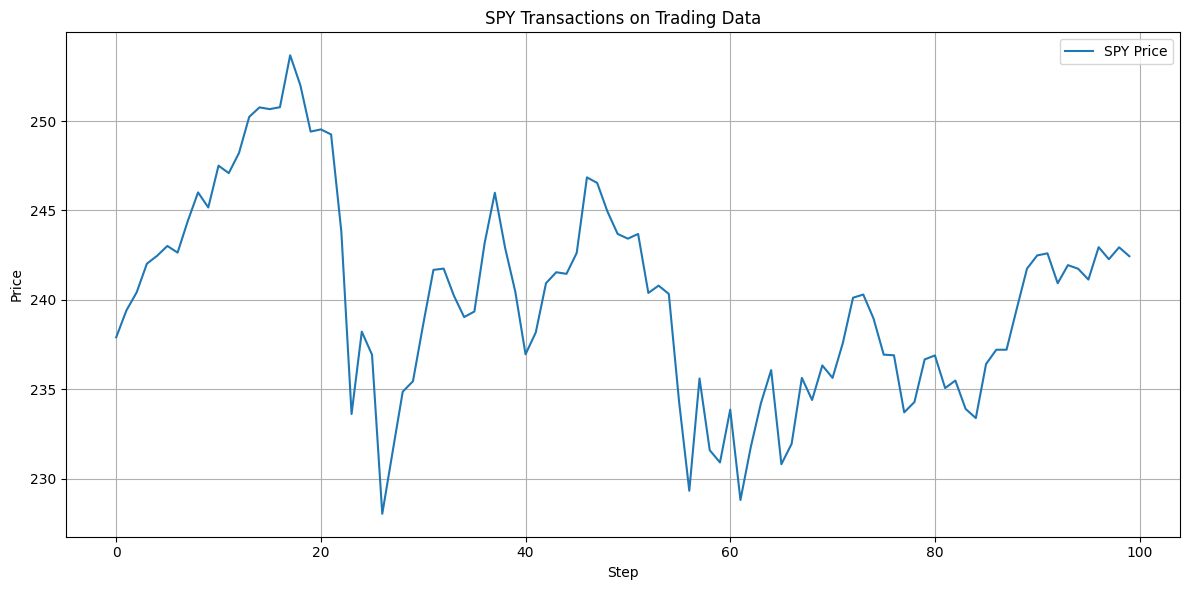

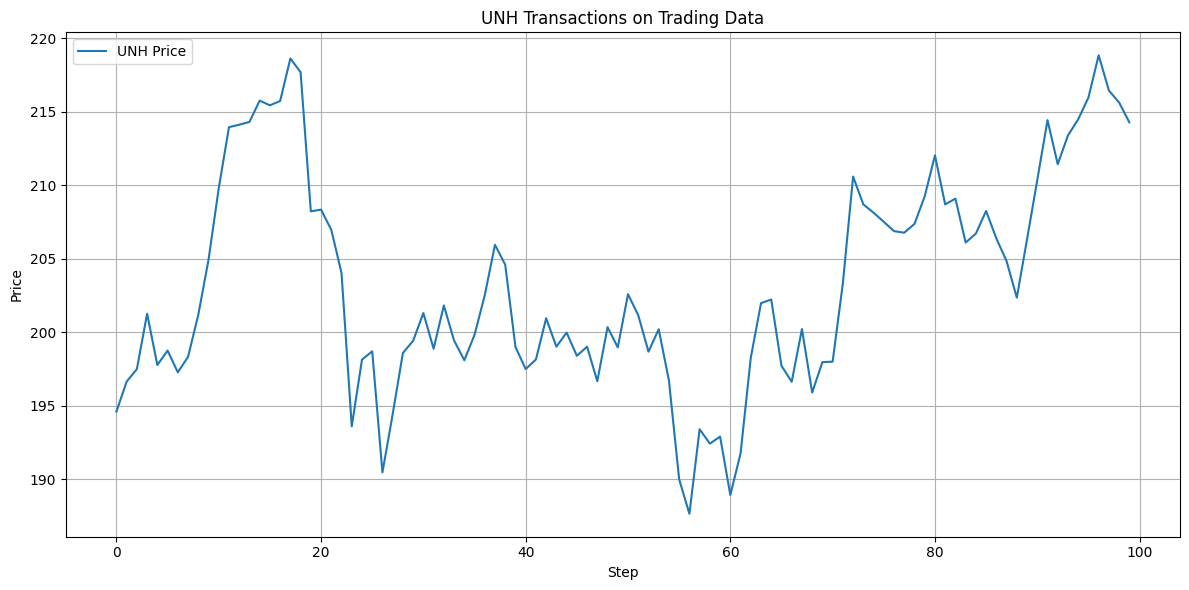

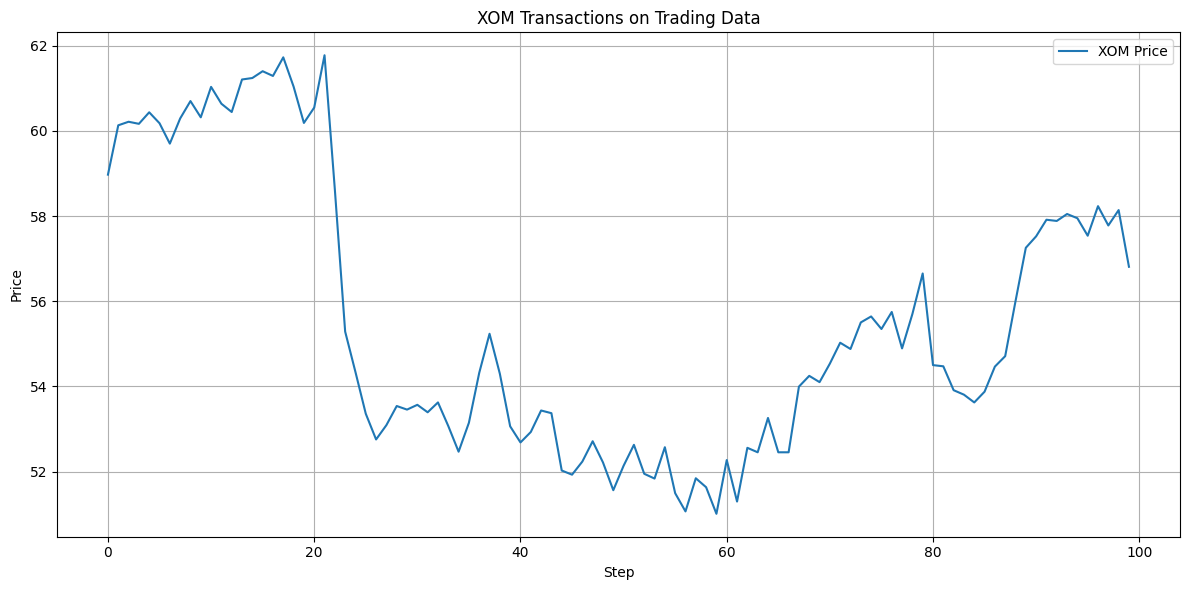

In [18]:
%matplotlib inline
tickers = trade_df['tic'].unique()

for tic in tickers:
    fig, ax = plot_trades_on_price_from_backtest(res, ticker=tic)